In [1]:
import pandas as pd

# Data Cleaning

I collaborated with ChatGPT and Claude to clean up my edgelist. Since I already crawled the internet, it was able to just use my JSON data rather than crawl a thousand websites. Much faster I got good results this way. I can now use this approach to expand into any location in the world.

In [2]:
data = r'C:\Users\itsgo\PythonCode\verdant_intelligence\exports\japan_edgelist_20260719.csv'
data = r'C:\Users\itsgo\PythonCode\verdant_intelligence\exports\japan_edgelist_chatgpt.csv'

df = pd.read_csv(data)
df.dropna(inplace=True)
df

,domain,page_title,linked_domains
0,okinawa-karate.okinawa,第3回沖縄空手世界大会 OKINAWA KARATE WORLD FESTIVAL〜 DEM...,bluesteakwonder.com
1,adnkronos.com,"News in tempo reale, ultime notizie e video | ...",japanese.adnkronos.com
2,okinawatraveler.net,沖縄観光に役立つおトクな最新情報が満載【Okinawa Traveler（沖縄トラベラー）,okinawalikes-shop.okinawatraveler.net
3,tokyobus.jp,東京バス株式会社 | TOKYO BUS,newstartour.jp
4,dmgevents.com,dmg events | a leading organiser of face-to-fa...,japanenergyevent.com
...,...,...,...
643,thetitanawards.com,TITAN Business Awards,thetokyodesignawards.com
644,musicawardsjapan.com,MUSIC AWARDS JAPAN,prtimes.jp
645,coindeskjapan.com,NADA NEWS（ナダ・ニュース） | 暗号資産（仮想通貨）とWeb3のビジネスニュースメディア,facebook.com
646,otomo.net,OTOMO（オトモ）| CEIPA / MUSIC AWARDS JAPAN公式メディア,youtube.com


In [3]:
# I will use this for my filtering and to understand the scale. i am not going to show the results. 
# there are so many adult websites, and that has been true since day one of the internet
# if you do OSINT, you typically want to filter them out
junk_mask = df['page_title'].str.contains('porn|sex|jav|singles|dating|escort|hentai|voyeur|naked|xxx|adult', case=False)

junk_df = df[junk_mask]
junk_df.shape

(7, 3)

In [4]:
df = df[~junk_mask].copy() # if you want the opposite of the filter, then you use the ~ mark
df.head()

,domain,page_title,linked_domains
0,okinawa-karate.okinawa,第3回沖縄空手世界大会 OKINAWA KARATE WORLD FESTIVAL〜 DEM...,bluesteakwonder.com
1,adnkronos.com,"News in tempo reale, ultime notizie e video | ...",japanese.adnkronos.com
2,okinawatraveler.net,沖縄観光に役立つおトクな最新情報が満載【Okinawa Traveler（沖縄トラベラー）,okinawalikes-shop.okinawatraveler.net
3,tokyobus.jp,東京バス株式会社 | TOKYO BUS,newstartour.jp
4,dmgevents.com,dmg events | a leading organiser of face-to-fa...,japanenergyevent.com


In [5]:
df.shape

(631, 3)

In [6]:
df['page_title'].value_counts()[0:50]

page_title
4F 2026 | Future Frontier Fes by FINOLAB – Japan’s Leading Fintech Event                                                                                                                                                                             50
MCCS Okinawa                                                                                                                                                                                                                                         40
Global Financial City OSAKA – 国際金融都市大阪                                                                                                                                                                                                               29
ベンチャーカフェ東京｜Venture Café Tokyo                                                                                                                                                                                                                        

# Graph Analysis

My goal is to identify several websites that talk about aspects of life in Japan, including but not limited to music, art, and events. Mainly, I want to remove junk and see what is left that may be useful as a source of information. Then I will inspect closer once I have an overall map.

In [7]:
import networkx as nx
import numpy as np
import pandas as pd

# for the explode statement; convert string to list
from ast import literal_eval

# for visualization
from IPython.display import SVG 
from sknetwork.visualization import svg_graph 
from sknetwork.data import Bunch 
from sknetwork.ranking import PageRank 
from scipy.sparse import csr_matrix

def draw_graph(G, show_names=False, node_size=1, font_size=10, edge_width=0.5):

    adjacency = nx.to_scipy_sparse_array(G, nodelist=None, dtype=None, weight='weight', format='csr')
    adjacency = csr_matrix(adjacency) # fix to weird sknetwork-csr issue; comment out to troubleshoot
    
    names = np.array(list(G.nodes))
    
    graph = Bunch()
    graph.adjacency = adjacency
    graph.names = np.array(names)
    
    pagerank = PageRank()
    scores = pagerank.fit_transform(adjacency)

    if show_names:
        
        image = svg_graph(graph.adjacency, font_size=font_size, node_size=node_size, names=graph.names, width=700, height=500, scores=scores, edge_width=edge_width)
    
    else:
        
        image = svg_graph(graph.adjacency, node_size=node_size, width=700, height=500, scores = scores, edge_width=edge_width)
    
    return SVG(image)

In [8]:
G = nx.from_pandas_edgelist(df, 'domain', 'linked_domains')
print(G)

Graph with 556 nodes and 611 edges


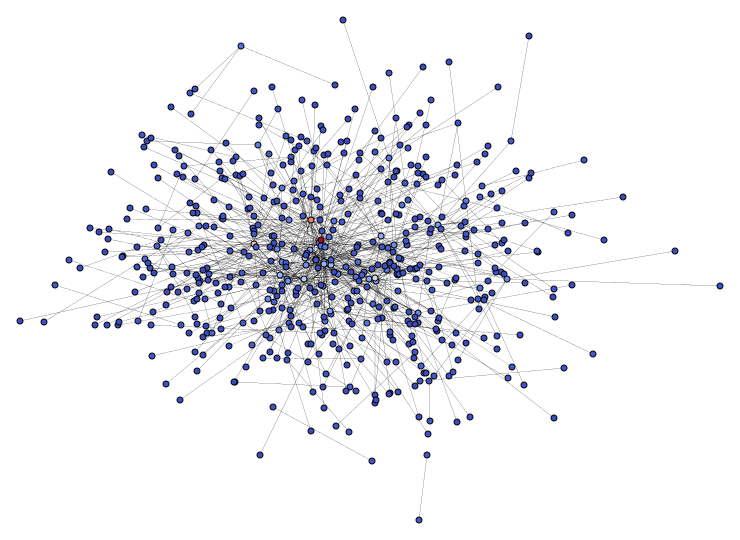

In [9]:
draw_graph(G, edge_width=0.1, node_size=3)

I originally used my pre-LLM graph methods, but then I had an idea to save a lot of time, so collaborated with AI (Claude and ChatGPT) to filter the edgelist directly rather than crawling hundreds of websites. I already did that for them, which made the collaboration a lot faster.

I am hunting for 1) news, 2) music, 3) art, 4) cultural informaiton, 5) event information, 6) other information families use.

Let's use Page Rank and Egocentric Network Analysis to zoom in with our Graph Microscope. :)

In [10]:
[n for n in sorted(G.nodes) if 'city' in n.lower()] # other city nodes

['city.hamamatsu.shizuoka.jp',
 'city.nagoya.jp',
 'city.nanjo.okinawa.jp',
 'city.osaka.lg.jp',
 'city.sapporo.jp',
 'fincity.tokyo',
 'global-financial-city-osaka.jp',
 'hide-city.com',
 'myvancity.ca',
 'neo.tokyonight.city',
 'okinawacity.spoyell.okinawa',
 'saascity.io',
 'tokyocitykeiba.com',
 'yourcitywithin.com']

In [11]:
keywords = ['city', 'okinawa', 'tokyo', 'osaka']

[n for n in sorted(G.nodes) if any(kw in n.lower() for kw in keywords)]

['4f-otmcbldg.tokyo',
 'beokinawa.jp',
 'busnavi-okinawa.com',
 'city.hamamatsu.shizuoka.jp',
 'city.nagoya.jp',
 'city.nanjo.okinawa.jp',
 'city.osaka.lg.jp',
 'city.sapporo.jp',
 'community.venturecafetokyo.org',
 'cruise.visitokinawa.jp',
 'english.metro.tokyo.lg.jp',
 'english.tokyobus.jp',
 'fincity.tokyo',
 'finolab.tokyo',
 'gbh-tokyo.or.jp',
 'global-financial-city-osaka.jp',
 'handsfree.okinawa',
 'hibiya.tokyo-midtown.com',
 'hide-city.com',
 'j1fm.tokyo',
 'jfia.tokyo',
 'kankou-nanjo.okinawa',
 'karate-week.okinawa',
 'mccsokinawa.com',
 'medialibrary.okinawastory.jp',
 'metro.tokyo.lg.jp',
 'myvancity.ca',
 'neo.tokyonight.city',
 'ocatokyo.jp',
 'okinawa-karate.okinawa',
 'okinawa.stripes.com',
 'okinawa.usmc-mccs.org',
 'okinawabus.com',
 'okinawacity.spoyell.okinawa',
 'okinawahai.com',
 'okinawakarate-unesco.jp',
 'okinawalikes-shop.okinawatraveler.net',
 'okinawanews.org',
 'okinawapass.com',
 'okinawasportsisland.jp',
 'okinawastory.jp',
 'okinawatimes.co.jp',
 'okin

# Page Rank Analysis

Let's see what Page Rank thinks are the most important nodes in the graph.

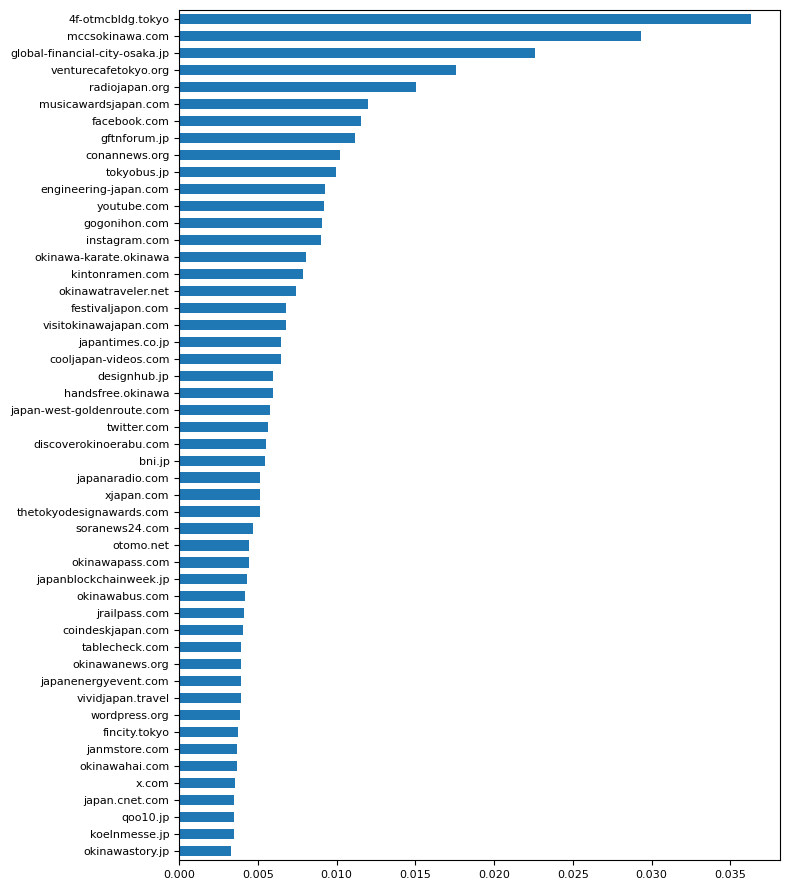

In [12]:
import matplotlib.pyplot as plt

top_domains = pd.Series(nx.pagerank(G)).sort_values(ascending=False)[:50]
top_domains[::-1].plot.barh(figsize=(8, 9), width=0.6, fontsize=8)
plt.tight_layout()

In [13]:
def draw_ego(G, center, radius=1, node_size=4, show_names=True):

    ego = nx.ego_graph(G, center, radius=radius)

    for domain in sorted(ego.nodes):
        print(domain)
        
    return draw_graph(ego, node_size=node_size, show_names=show_names)

0club.jp
10x1000.org
4f-otmcbldg.tokyo
agventurelab.or.jp
aiagent0306.peatix.com
alpaca.markets
austrade.eventsair.com
dainichiginkyo.or.jp
dcamp.kr
dentsusoken.com
docs.google.com
egg-japan.com
facebook.com
fdua.org
financial-hub-fukuoka.com
fincity.tokyo
finolab.co.jp
finolab.tokyo
finolabopenday2026.peatix.com
finopitch2026.peatix.com
fintechjapan.org
fintechspace.com.tw
fita.or.jp
forms.gle
gbh-tokyo.or.jp
gmo-aozora.com
goodway.co.jp
inspiredlab.jp
japan-d2.com
jetro.go.jp
jfia.tokyo
kddi.com
kigyorichi.pref.fukuoka.lg.jp
luma.com
mastercard.co.jp
mirailabpalette.jp
moneyx-asia.com
nochubank.or.jp
ocatokyo.jp
peatix.com
preferred.jp
pulse.growthstock.app
sapporo-step.global
sbbit.jp
sevenbank.co.jp
startupisland.tw
tokyo-card.co.jp
trustbase.co.jp
xtech.mec.co.jp
youtube.com


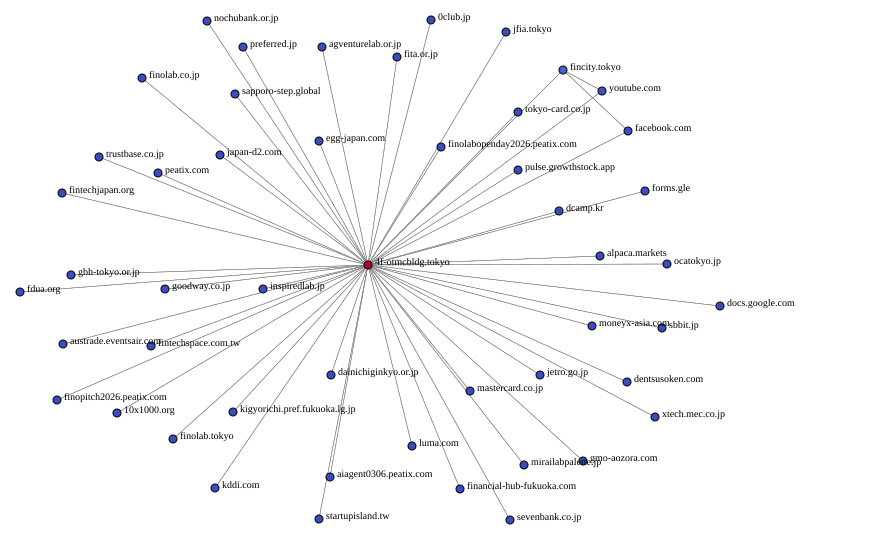

In [14]:
draw_ego(G, top_domains.index[0])

29palms.usmc-mccs.org
8thandi.usmc-mccs.org
988lifeline.org
albany.usmc-mccs.org
americanforcestravel.com
barstow.usmc-mccs.org
bestvpn.org
bridgeport.usmc-mccs.org
campfuji.usmc-mccs.org
careers.usmc-mccs.org
cherrypoint.usmc-mccs.org
dodcio.defense.gov
eeoc.gov
err.usmc-mccs.org
facebook.com
foia.gov
hamptonroads.usmc-mccs.org
hawaii.usmc-mccs.org
hendersonhall.usmc-mccs.org
instagram.com
iwakuni.usmc-mccs.org
lejeunenewriver.usmc-mccs.org
lp.constantcontactpages.com
marines.com
marines.mil
mccsmcrd.com
mccsokinawa.com
militaryonesource.mil
miramar.usmc-mccs.org
mujuk.usmc-mccs.org
mymcx.com
okinawa.usmc-mccs.org
pendleton.usmc-mccs.org
quantico.usmc-mccs.org
safehelpline.org
southcarolina.usmc-mccs.org
veteranscrisisline.net
wrr.usmc-mccs.org
youtube.com
yuma.usmc-mccs.org


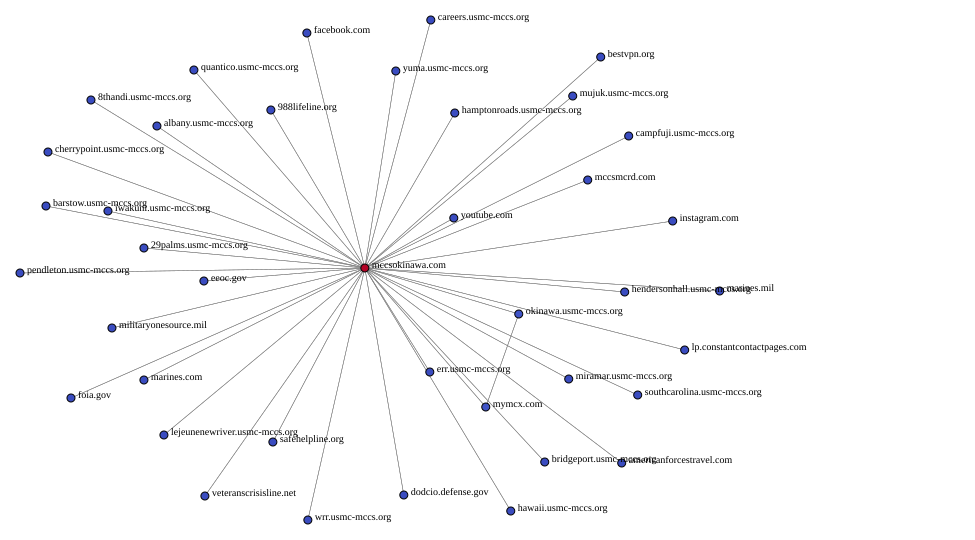

In [15]:
draw_ego(G, top_domains.index[1])

altairjp.co.jp
alteryx.com
amfc.com.tw
baincapital.co.jp
bankchb.com
dozanpartners.jp
expo2025.or.jp
fgi.co.jp
fintechjapan.org
firstbank.com.tw
global-financial-city-osaka.jp
hashport.io
layerx.co.jp
linkedin.com
marathoncapital.co.jp
medtechactuator.com
monexventures.com
morganstanley.co.jp
odx.co.jp
sasukefinlab.com
sbro.co.jp
spacianet.co.jp
teneopartners.co.jp
theseed.vc
ticketme.co.jp
tokyotanshi.co.jp
trinity-tech.co.jp
twitter.com
umekita2.jp
webx-asia.com


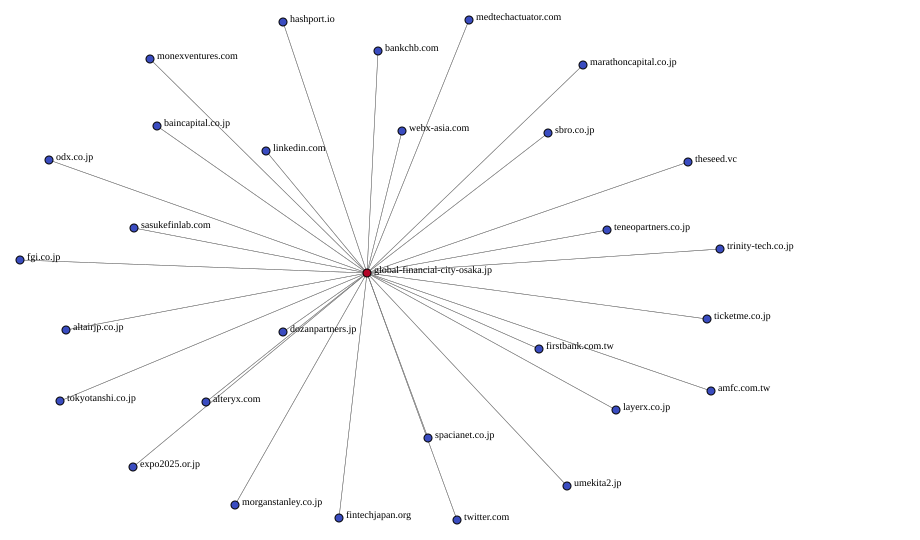

In [16]:
draw_ego(G, top_domains.index[2])

americanexpress.com
community.venturecafetokyo.org
venturecafe-yokohamaconnect.org
venturecafeberlin.org
venturecafecambridge.org
venturecafecambridgeconnect.org
venturecafeedinburgh.org
venturecafefukuoka.org
venturecafeglobal.org
venturecafelondon.org
venturecafemanchester.org
venturecafemiami.org
venturecafemonterrey.org
venturecafephiladelphia.org
venturecafephoenix.org
venturecafeprovidence.org
venturecaferotterdam.org
venturecafestl.org
venturecafesydney.org
venturecafetokyo.org
venturecafewarsaw.org


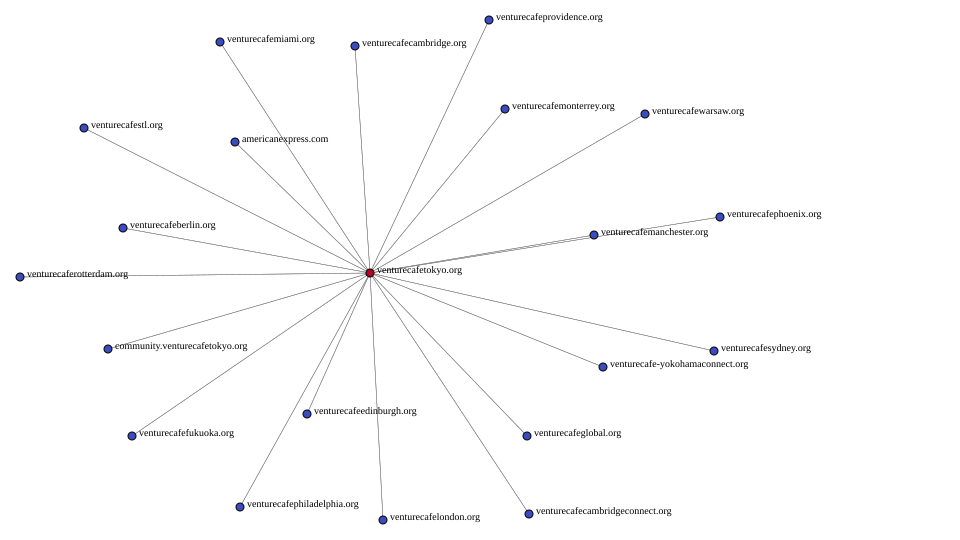

In [17]:
draw_ego(G, top_domains.index[3])

canadaradiostations.com
fmradiofree.com
greek-radio.org
internetradio-schweiz.ch
radio-australia.org
radio-ghana.org
radio-ireland.com
radio-jamaica.com
radio-kenya.com
radio-nederland.nl
radio-nigeria.com
radio-osterreich.at
radio-philippines.com
radio-romania.com
radioindia.in
radiojapan.org
radiomalaysia.org
top-charts.com


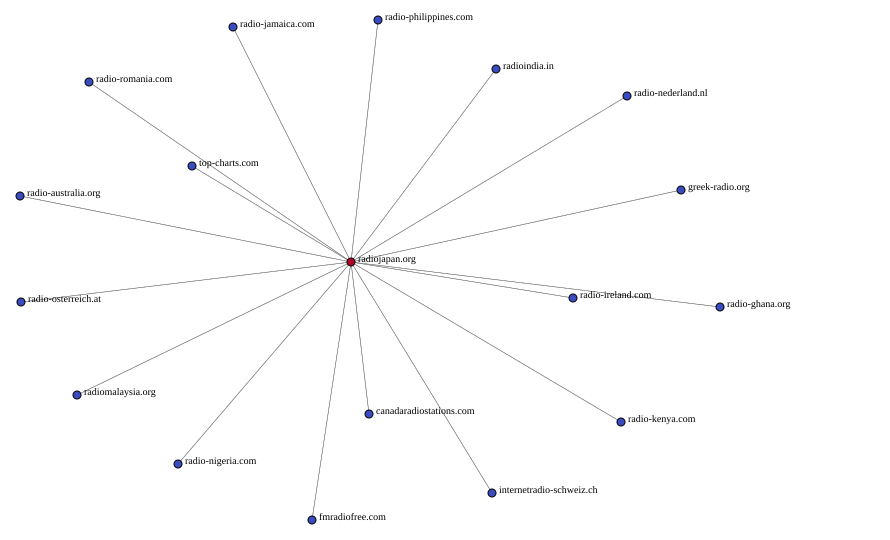

In [18]:
draw_ego(G, top_domains.index[4])

abema.tv
ceipa.net
e.usen.com
events.musicawardsjapan.com
facebook.com
instagram.com
lemino.docomo.ne.jp
lin.ee
maj-vocaloid.com
musicawardsjapan-store.online
musicawardsjapan.com
otomo.net
prtimes.jp
spotify.link
tiktok.com
timetr.ee
timetreeapp.com
tunecore.co.jp
wd-inc.jp
x.com
youtube.com


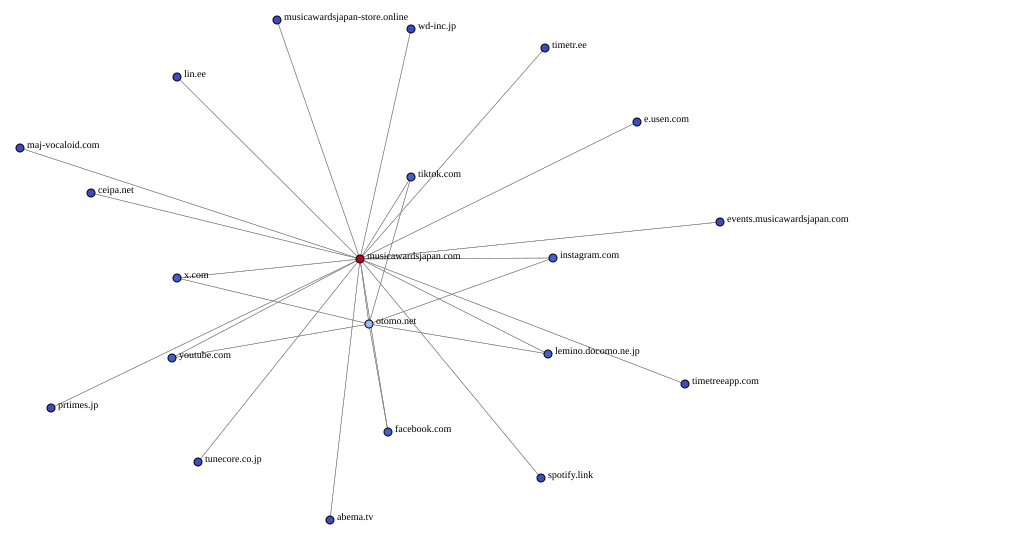

In [19]:
draw_ego(G, top_domains.index[5])

4f-otmcbldg.tokyo
coindeskjapan.com
conannews.org
cooljapan-videos.com
designhub.jp
facebook.com
festivaljapon.com
fincity.tokyo
gogonihon.com
janmstore.com
japan-west-goldenroute.com
jrailpass.com
kintonramen.com
mccsokinawa.com
musicawardsjapan.com
okinawa-karate.okinawa
okinawahai.com
okinawatraveler.net
otomo.net
soranews24.com
tablecheck.com
tokyo-marunouchi.jp
tokyobus.jp
visitokinawajapan.com


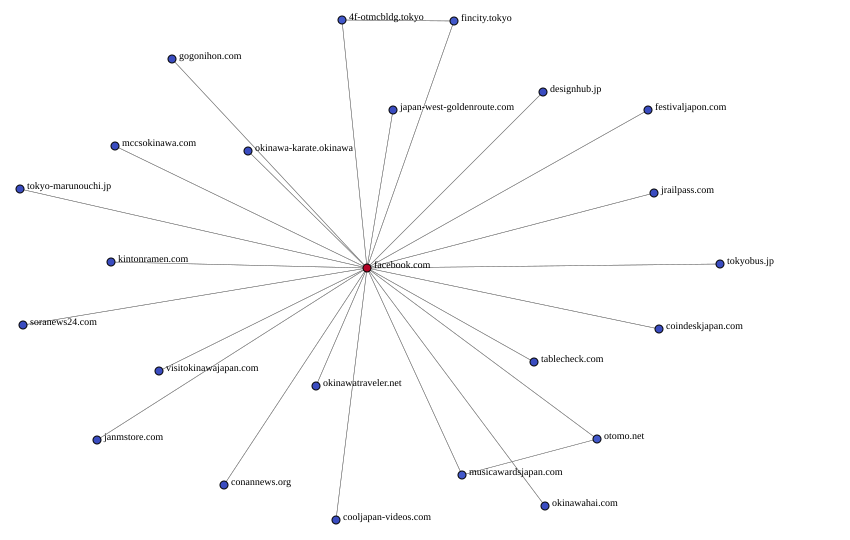

In [20]:
draw_ego(G, top_domains.index[6])

city.nagoya.jp
city.sapporo.jp
digital.go.jp
english.metro.tokyo.lg.jp
fincity.tokyo
fintechfestival.sg
fsa.go.jp
gftnforum.jp
gov.uk
investhk.gov.hk
jetro.go.jp
mas.gov.sg
metro.tokyo.lg.jp
oliverwyman.com
paih.gov.pl
philippinefintechfestival.ph


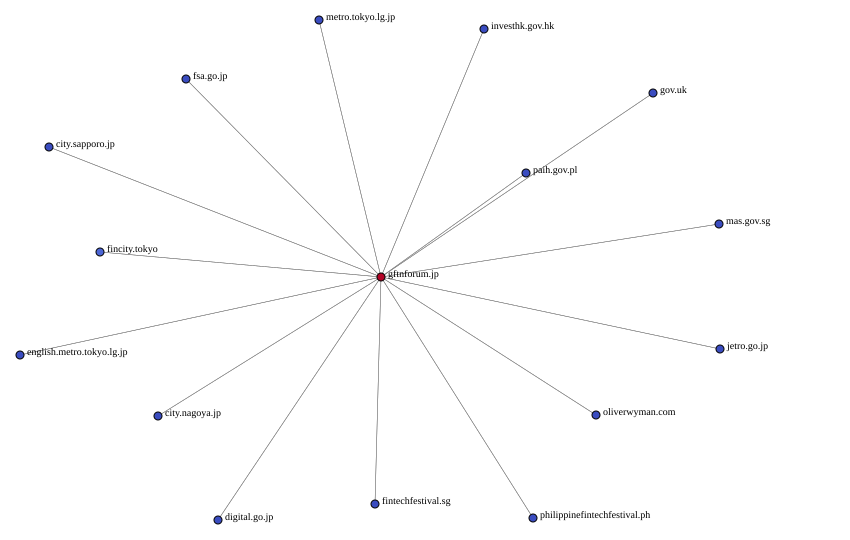

In [21]:
draw_ego(G, top_domains.index[7])

animepro.de
conanforum.org
conannews.org
conanwiki.org
crunchyroll.com
discordapp.com
facebook.com
instagram.com
joyn.de
manga-passion.de
manime.de
mastodon.social
themegrill.com
threads.net
wordpress.org
youtube.com


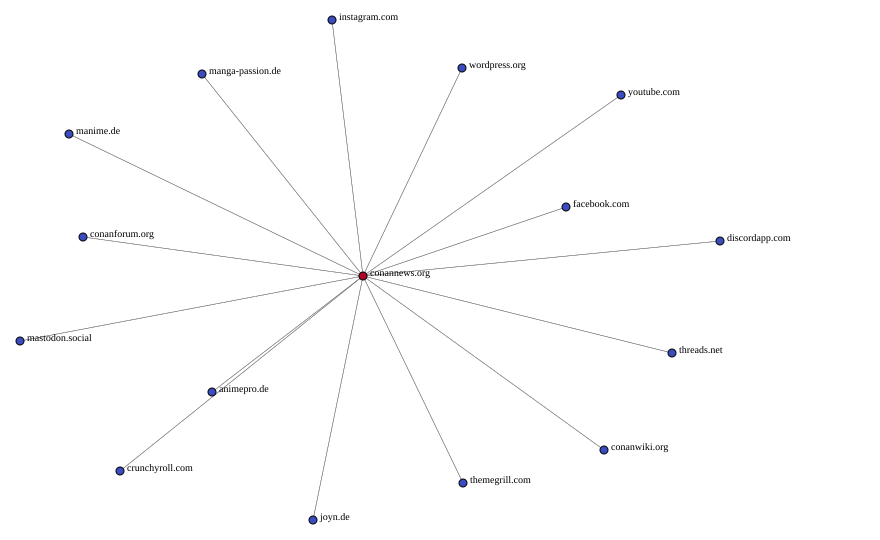

In [22]:
draw_ego(G, top_domains.index[8])

bunka-koutsu.jp
bus.or.jp
chatan-gateway.com
english.tokyobus.jp
facebook.com
hokkaidoubus-newstar.jp
hokubukankou-bus.com
job-gear.jp
nagoyabus.jp
newstartour.jp
osakabus.jp
osakakankobus.jp
tokyobus-group.com
tokyobus.jp
twitter.com
untenshashokuba.go.jp
wondercruise.jp
youtube.com


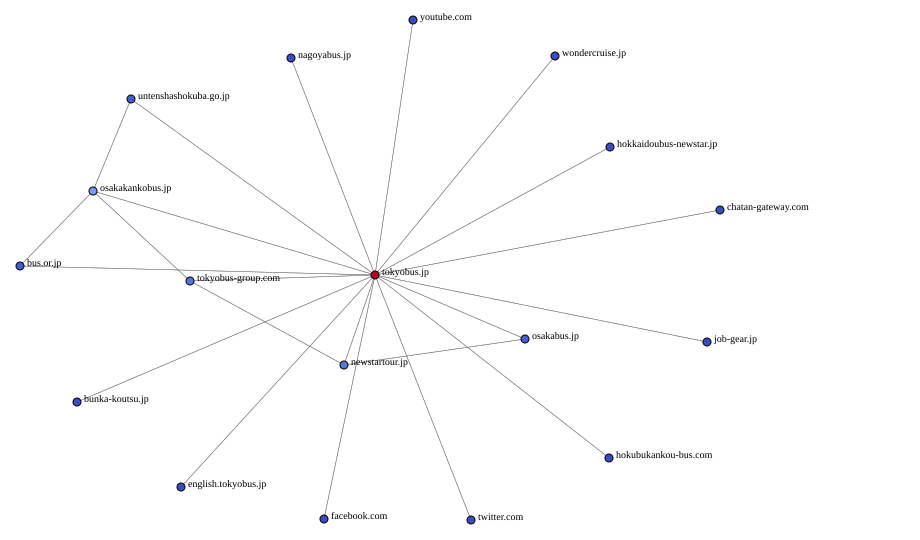

In [23]:
draw_ego(G, top_domains.index[9])

electronics-journal.com
engineering-japan.com
industrie-afrique-du-nord.com
industrieweb.fr
industry-asia-pacific.com
industry-australia.com
industry-india.com
industryemea.com
konstruktion-industrie.com
magazine-industry-usa.com
railway-international.com


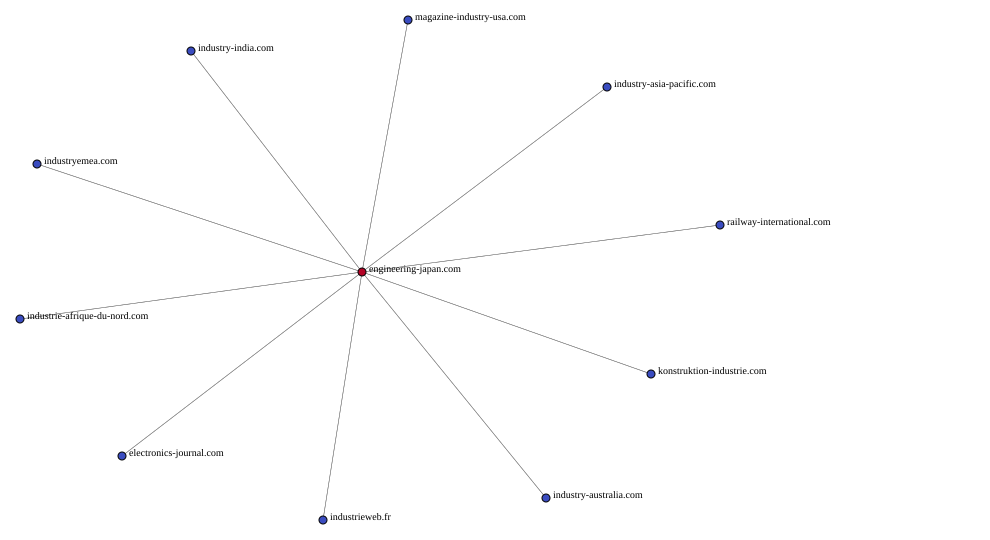

In [24]:
draw_ego(G, top_domains.index[10])

4f-otmcbldg.tokyo
conannews.org
designhub.jp
fincity.tokyo
gogonihon.com
handsfree.okinawa
janmstore.com
japan-west-goldenroute.com
mccsokinawa.com
musicawardsjapan.com
okinawa-karate.okinawa
okinawahai.com
okinawatraveler.net
otomo.net
soranews24.com
tokyo-marunouchi.jp
tokyobus.jp
visitokinawajapan.com
youtube.com


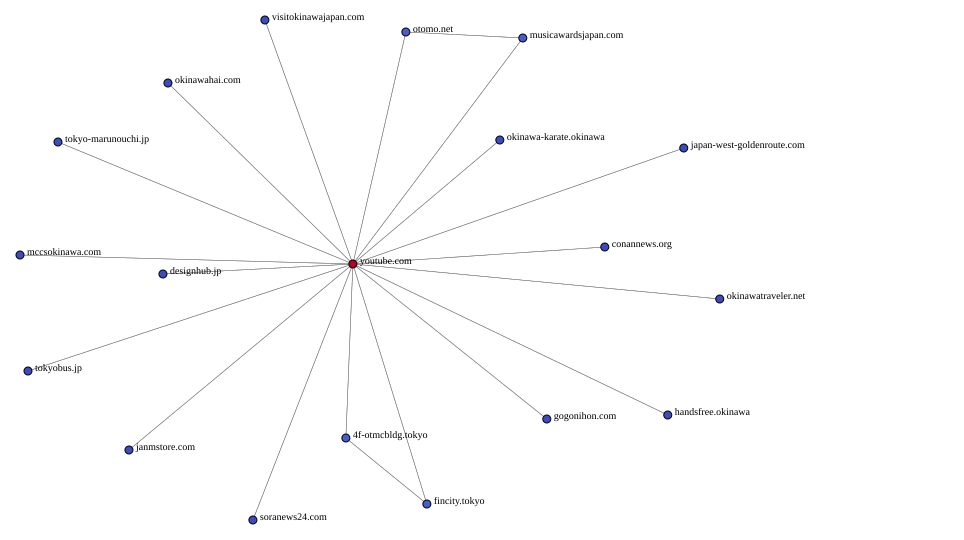

In [25]:
draw_ego(G, top_domains.index[11])

cookiedatabase.org
facebook.com
gogoenglish.com
gogoespana.com
gogofrance.com
gogohanguk.com
gogoitalia.com
gogonihon.com
gogoworld.com
instagram.com
japaneseonline.gogonihon.com
studyabroad.pub
studytrip.com
tiktok.com
youtube.com


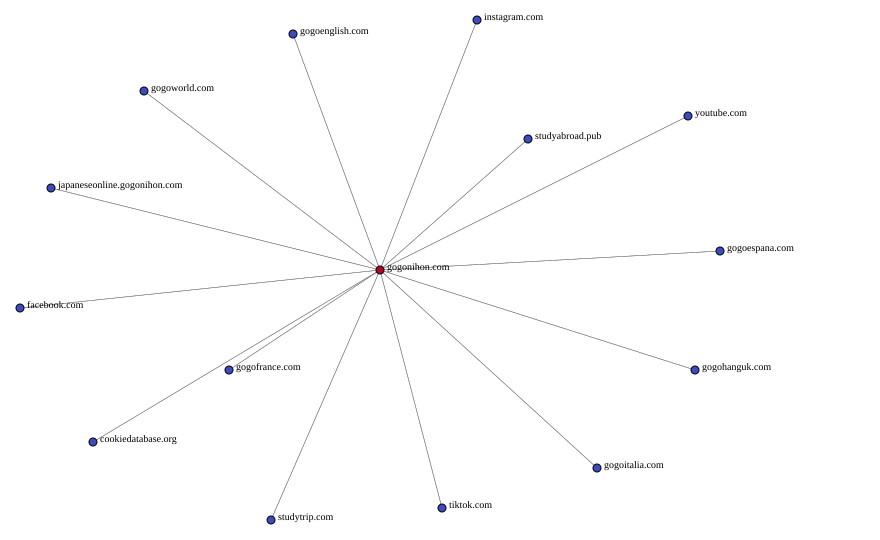

In [26]:
draw_ego(G, top_domains.index[12])


conannews.org
cooljapan-videos.com
festivaljapon.com
gogonihon.com
instagram.com
janmstore.com
japan-west-goldenroute.com
jrailpass.com
kintonramen.com
mccsokinawa.com
musicawardsjapan.com
okinawa-karate.okinawa
okinawahai.com
okinawatraveler.net
otomo.net
soranews24.com
tablecheck.com
tokyo-marunouchi.jp
visitokinawajapan.com


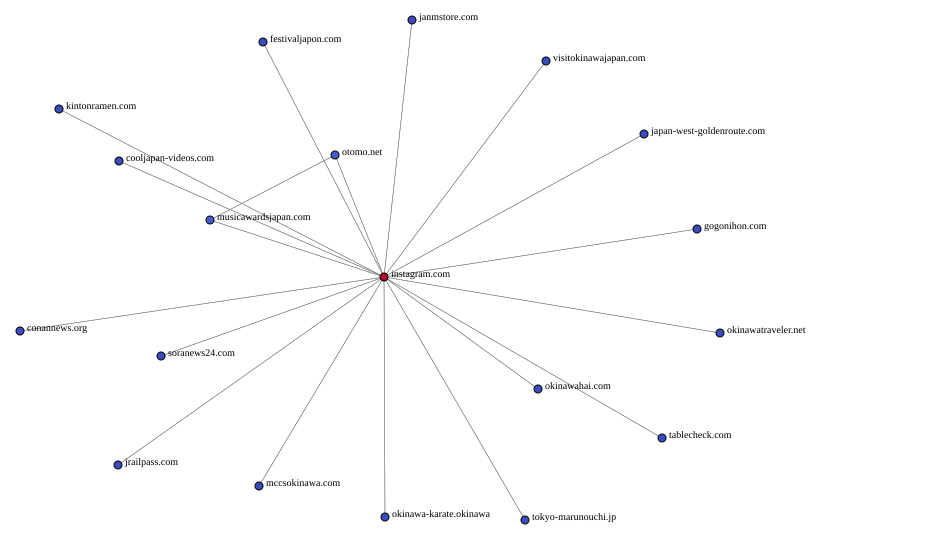

In [27]:
draw_ego(G, top_domains.index[13])


bluesteakwonder.com
facebook.com
instagram.com
karate-week.okinawa
karatekaikan.jp
lin.ee
odks.jp
okic.odks.jp
okinawa-karate.okinawa
okinawakarate-unesco.jp
pref.okinawa.jp
shureido-karate.com
x.com
youtube.com


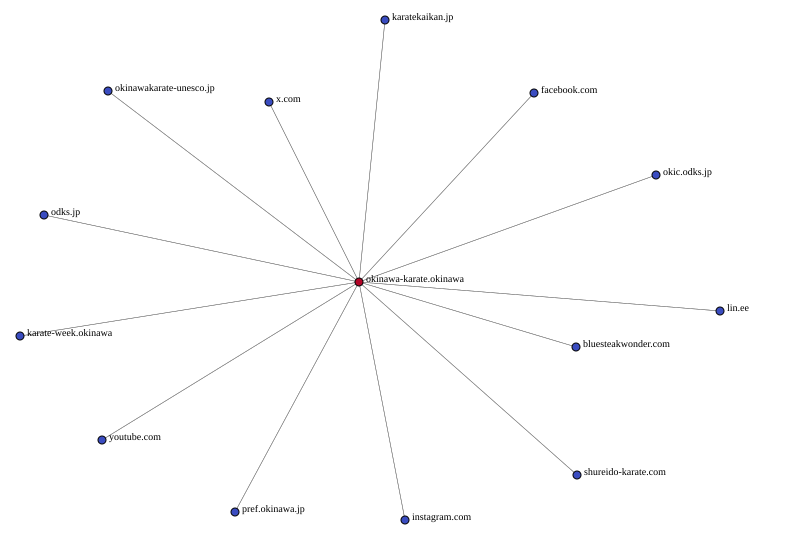

In [28]:
draw_ego(G, top_domains.index[14])


ca.linkedin.com
cfa.ca
facebook.com
foodtastic.ca
hungry416.com
instagram.com
kinkafamily.com
kintonramen.com
myvancity.ca
retail-insider.com
tiktok.com
twitter.com
yourcitywithin.com


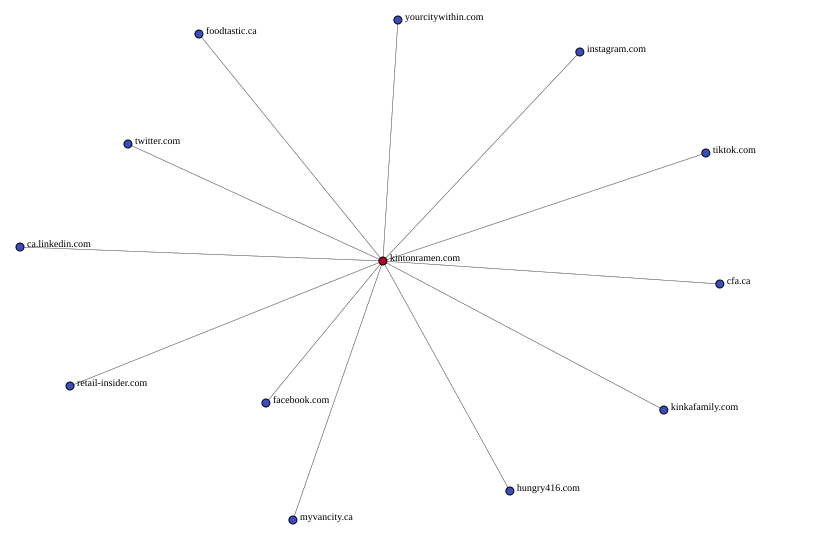

In [29]:
draw_ego(G, top_domains.index[15])


facebook.com
instagram.com
okinawalikes-shop.okinawatraveler.net
okinawapass.com
okinawatraveler.jcation.com
okinawatraveler.net
threads.net
twitter.com
webket.jp
widgets.bokun.io
yanbaru-adventure.com
youtu.be
youtube.com


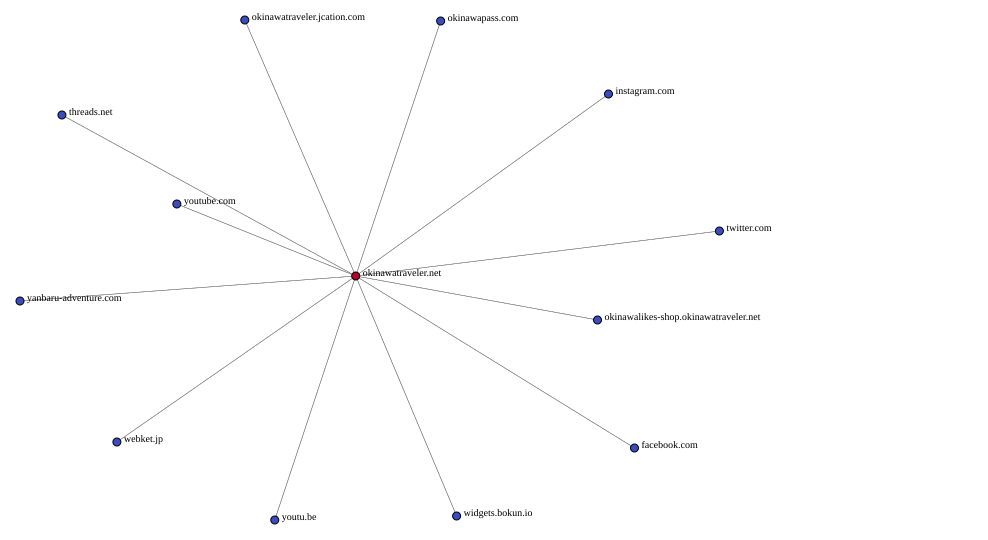

In [30]:
draw_ego(G, top_domains.index[16])

facebook.com
festivaljapon.com
forms.gle
instagram.com
jcccm-cccjm.ca
linktr.ee
maps.google.com
montreal.ca.emb-japan.go.jp
otakuthon.com
ozawa.ca
zeffy.com


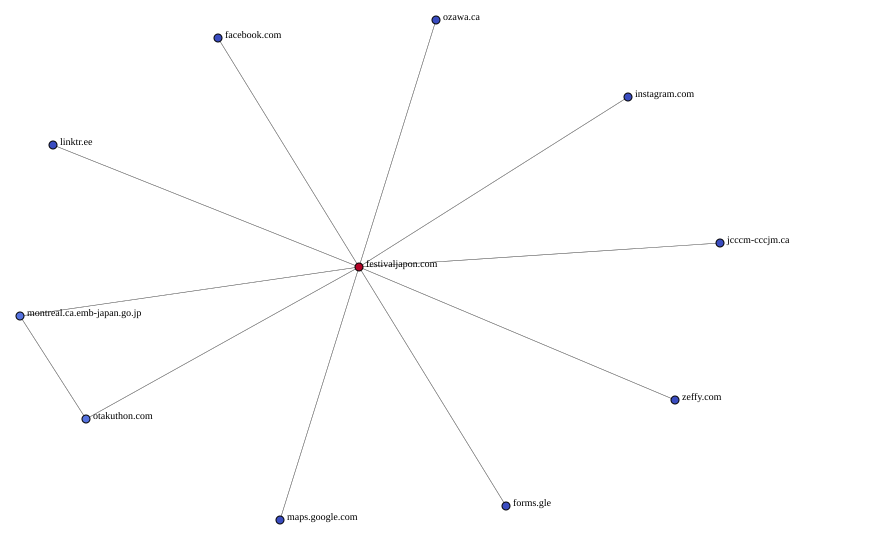

In [31]:
draw_ego(G, top_domains.index[17])

beokinawa.jp
facebook.com
instagram.com
japan.travel
ocvb.or.jp
okinawasportsisland.jp
okinawastory.jp
otic.okinawa
travel-brochures.okinawastory.jp
twitter.com
visitokinawajapan.com
youtube.com


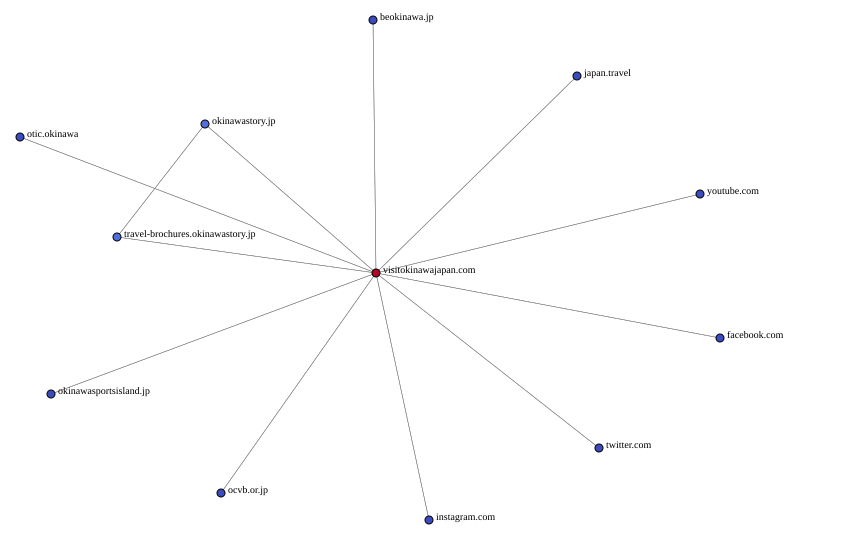

In [32]:
draw_ego(G, top_domains.index[18])

aldaily.com
ani.social
craigmod.com
drudgereport.com
japantimes.co.jp
refdesk.com
rense.com
restaurantdive.com


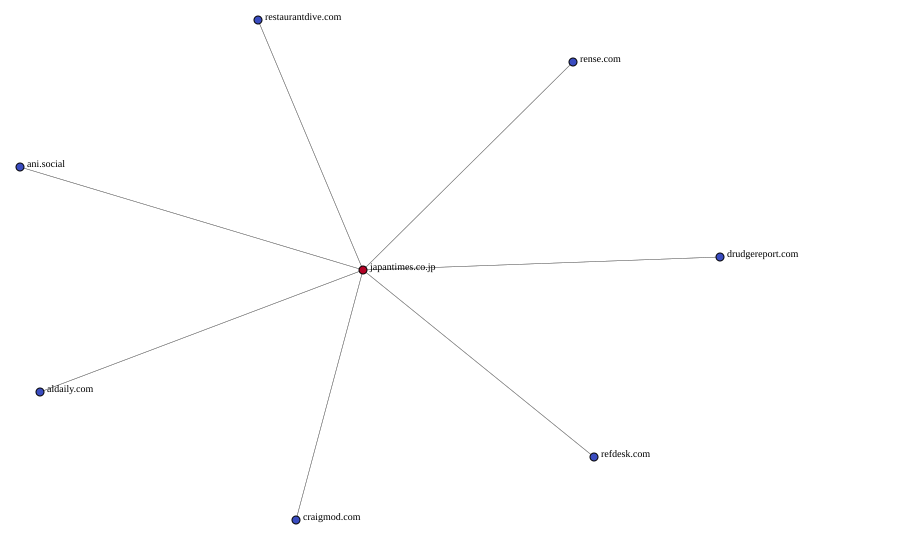

In [33]:
draw_ego(G, top_domains.index[19])


api.whatsapp.com
cooljapan-videos.com
facebook.com
instagram.com
linkedin.com
management.cooljapan-videos.com
pinterest.jp
reddit.com
tumblr.com
twitter.com
ultimedia.co.jp


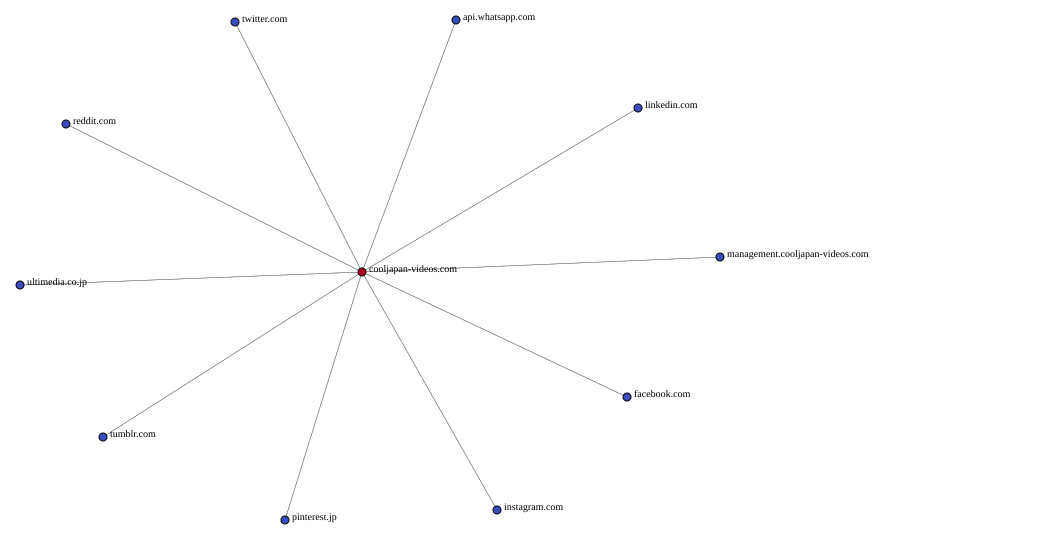

In [34]:
draw_ego(G, top_domains.index[20])


designhub.jp
eepurl.com
facebook.com
google.com
jagda.or.jp
jidp.or.jp
tokyo-midtown.com
tub.tamabi.ac.jp
twitter.com
youtube.com


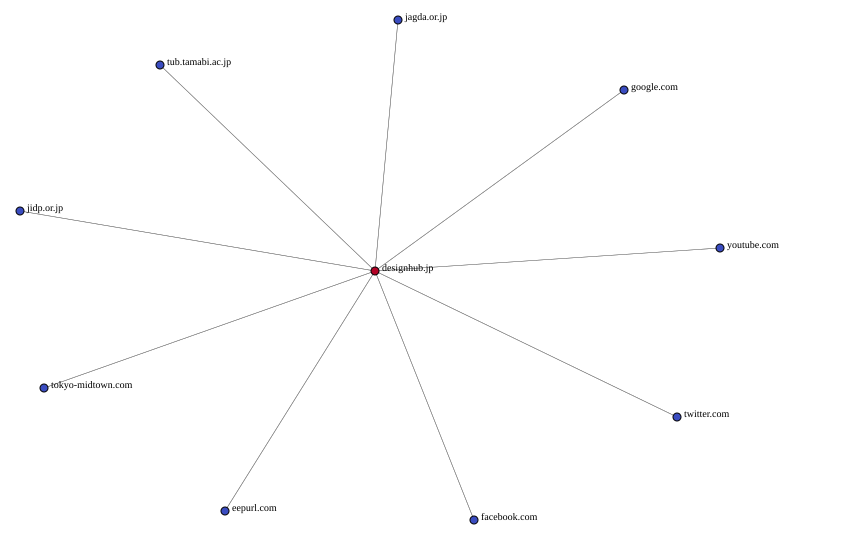

In [35]:
draw_ego(G, top_domains.index[21])


cloak.ecbo.io
handsfree-travel.org
handsfree.okinawa
jtb.co.jp
lugga-free.tap-app.com
pref.okinawa.jp
questant.jp
youtube.com
yui-rail.co.jp


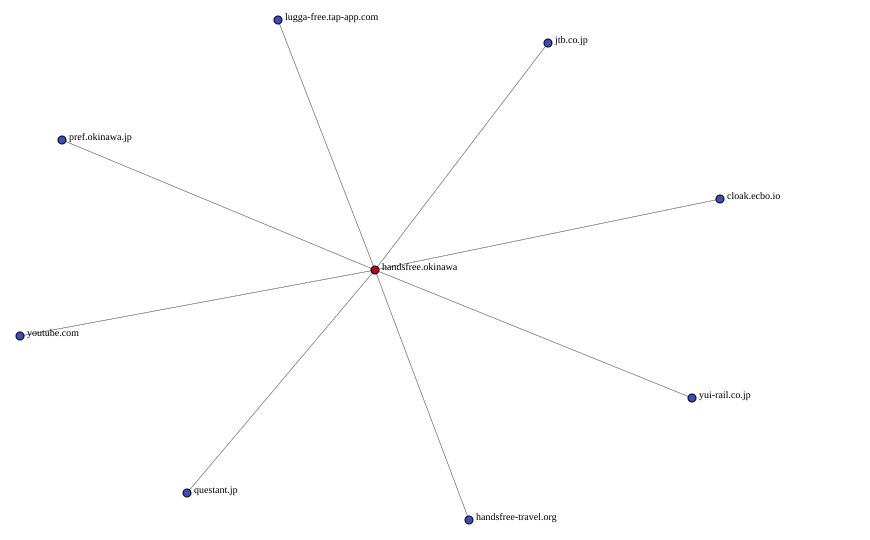

In [36]:
draw_ego(G, top_domains.index[22])


cookiedatabase.org
en.activityjapan.com
facebook.com
instagram.com
japan-west-goldenroute.com
kkday.com
setouchi-travelguide.com
tkts.tokyo
tp.media
youtube.com


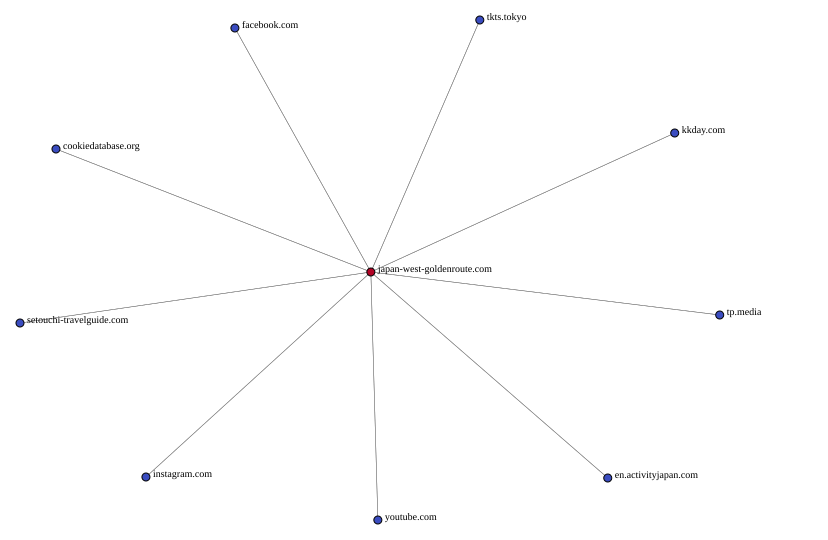

In [37]:
draw_ego(G, top_domains.index[23])


cooljapan-videos.com
designhub.jp
global-financial-city-osaka.jp
janmstore.com
jrailpass.com
kintonramen.com
okinawahai.com
okinawatraveler.net
soranews24.com
tokyobus.jp
twitter.com
visitokinawajapan.com


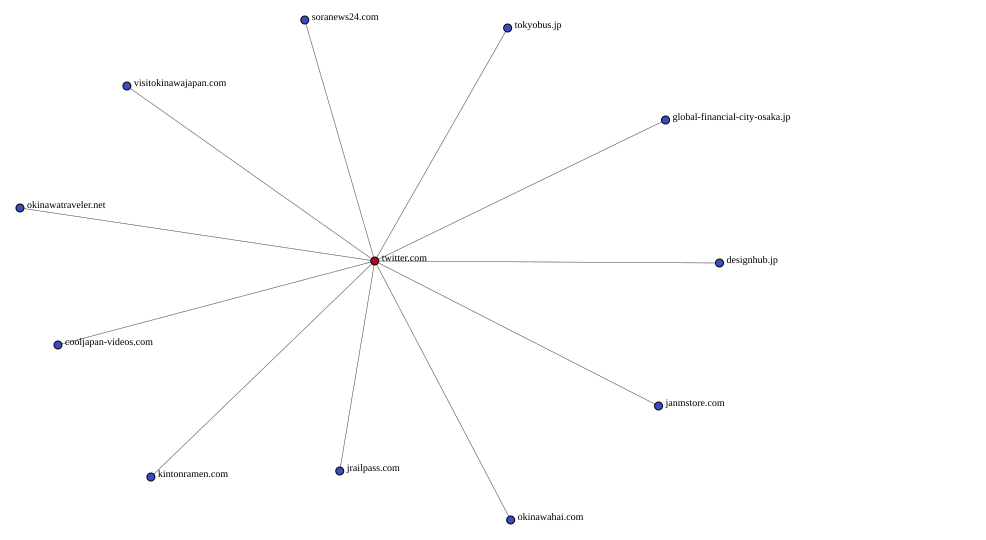

In [38]:
draw_ego(G, top_domains.index[24])


booking.com
discoverokinoerabu.com
expedia.com
jal.co.jp
kagoshima-kankou.com
tripadvisor.com


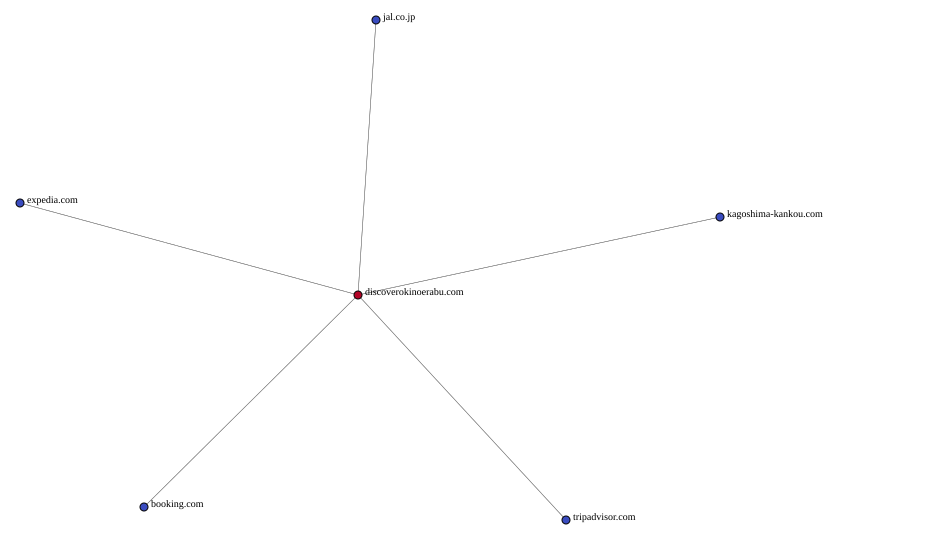

In [39]:
draw_ego(G, top_domains.index[25])


americanexpress.com
bni.jp
bnibusinessbuilder.com
bniuniversity.com
news.bni.jp
visitor.bni.jp
withwomentimes.com


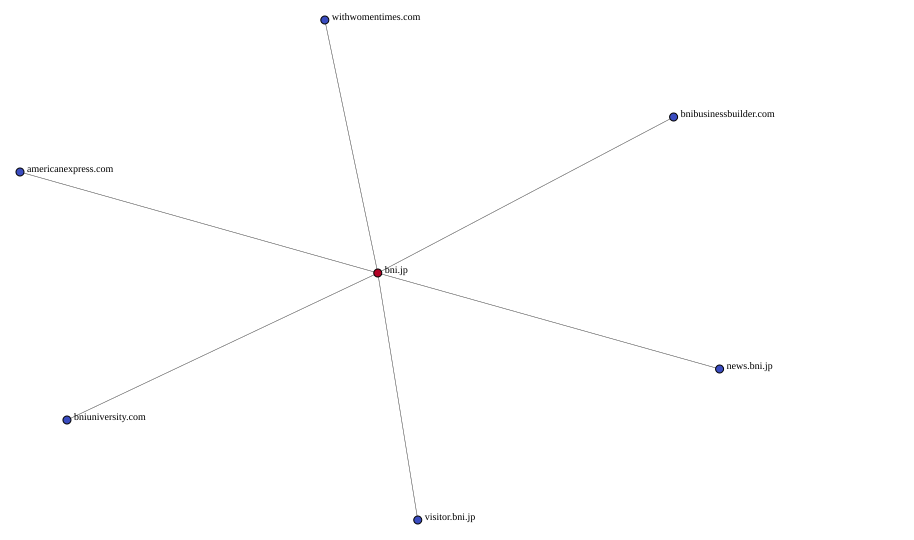

In [40]:
draw_ego(G, top_domains.index[26])


discord.gg
j1fm.tokyo
japanaradio.com
open.spotify.com
twitch.tv
unwoundshow.com


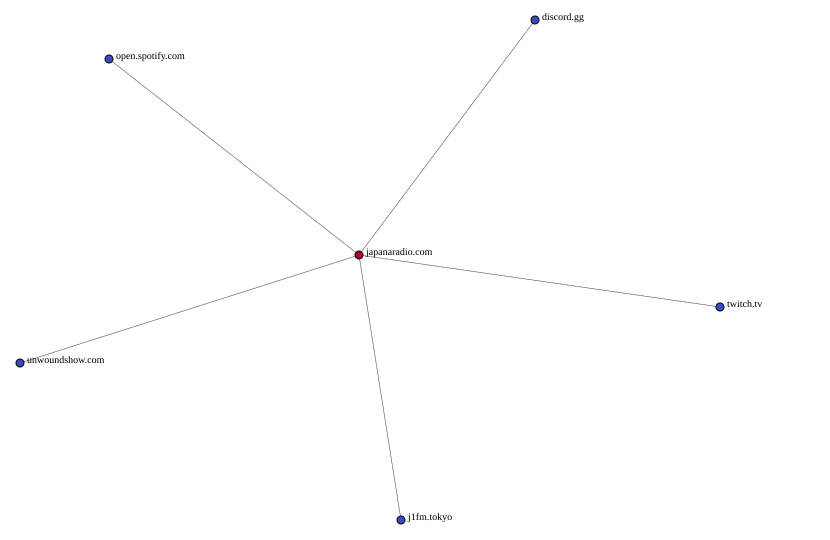

In [41]:
draw_ego(G, top_domains.index[27])


dailynews.com
grammymuseum.org
hide-city.com
music.mxdwn.com
thetimes.co.uk
xjapan.com


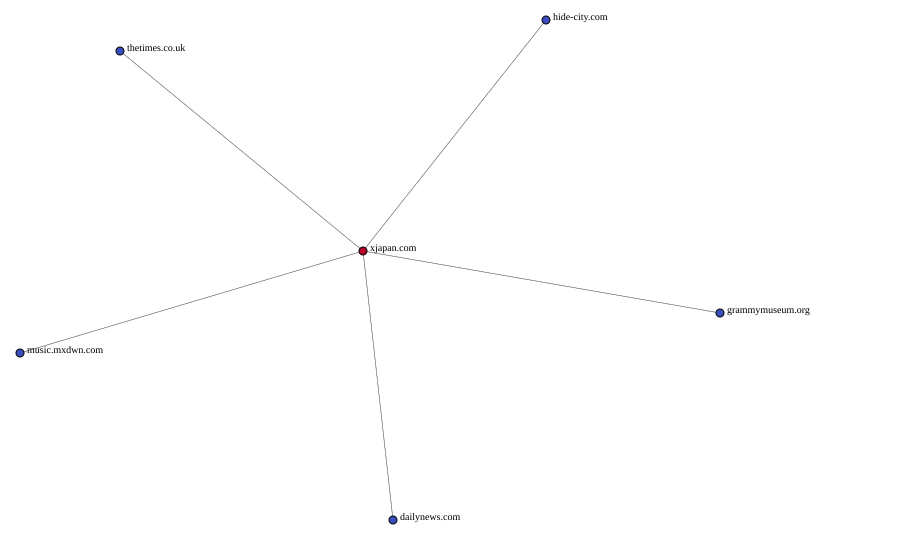

In [42]:
draw_ego(G, top_domains.index[28])


litmusicawards.com
nobleawards.com
thetitanawards.com
thetokyodesignawards.com
titanamericanbusinessawards.com
titanwomenleadershipawards.com


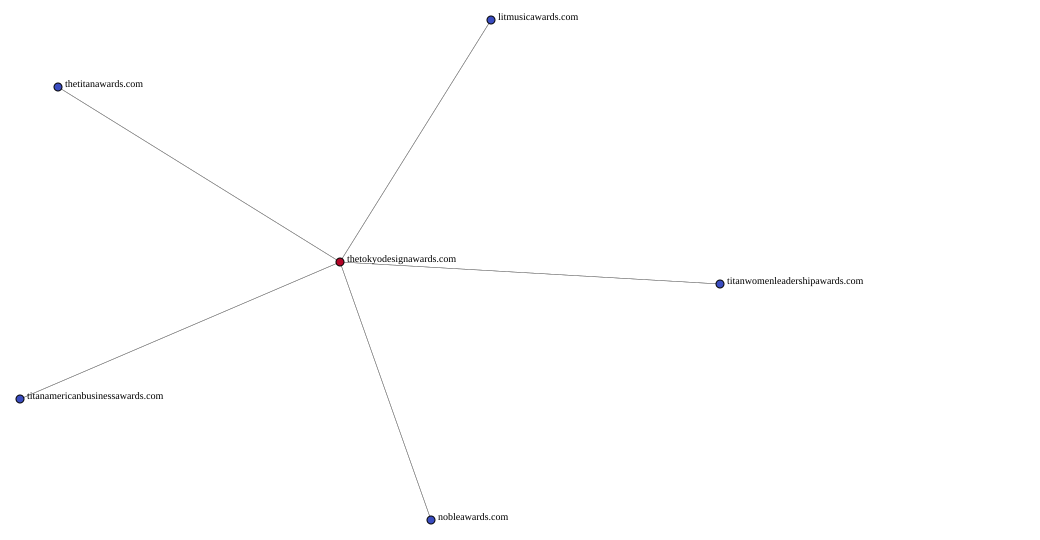

In [43]:
draw_ego(G, top_domains.index[29])


facebook.com
instagram.com
rocketnews24.com
soranews24.com
threads.com
twitter.com
wpvip.com
x.com
youtube.com


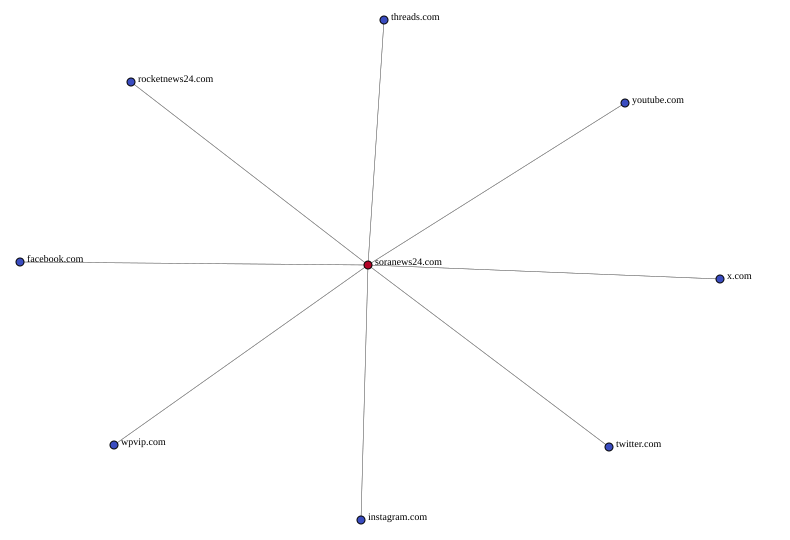

In [44]:
draw_ego(G, top_domains.index[30])


facebook.com
instagram.com
lemino.docomo.ne.jp
musicawardsjapan.com
otomo.net
skiyaki.com
tiktok.com
x.com
youtube.com


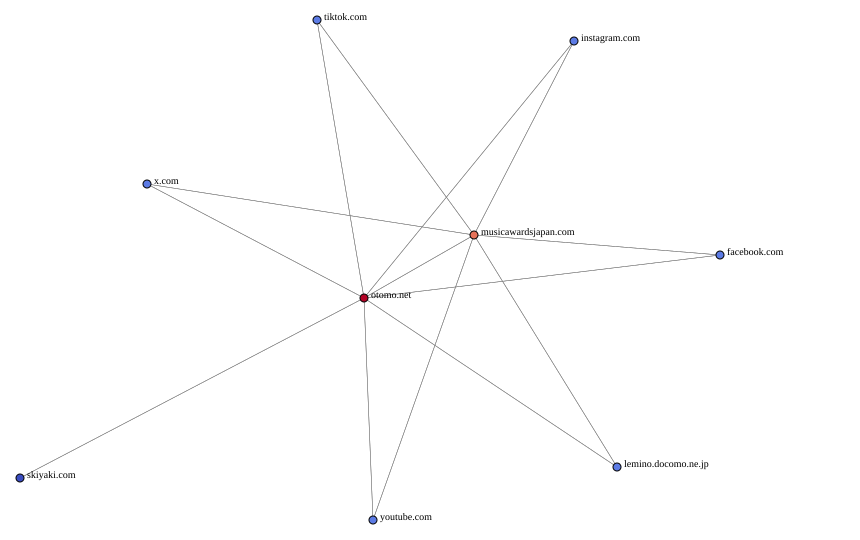

In [45]:
draw_ego(G, top_domains.index[31])


busnavi-okinawa.com
daiichibus.jp
okinawabus.com
okinawapass.com
okinawatraveler.net
ryukyubuskotsu.jp
toyobus.jp
yui-rail.co.jp


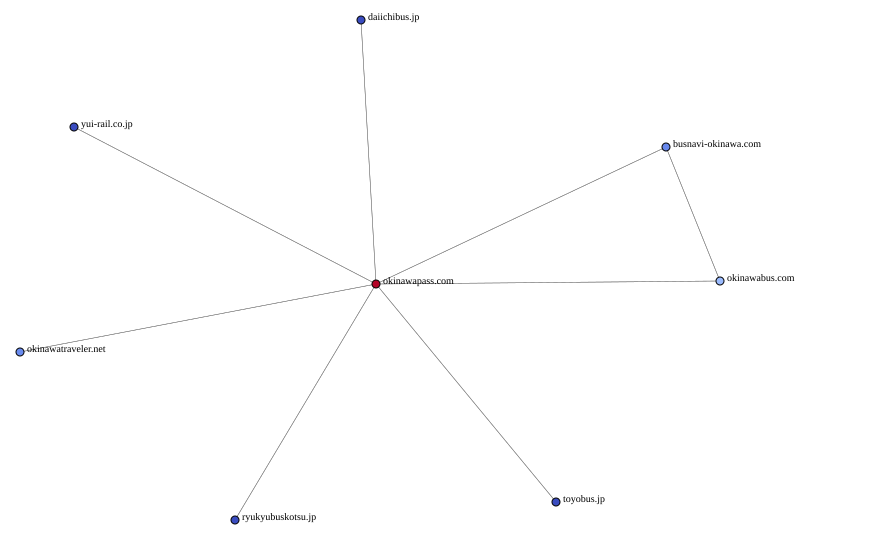

In [46]:
draw_ego(G, top_domains.index[32])


crypto-times.jp
futuremode.xyz
ivs.events
japanblockchainweek.jp
metaversestreetjournal.com
nadanews.com


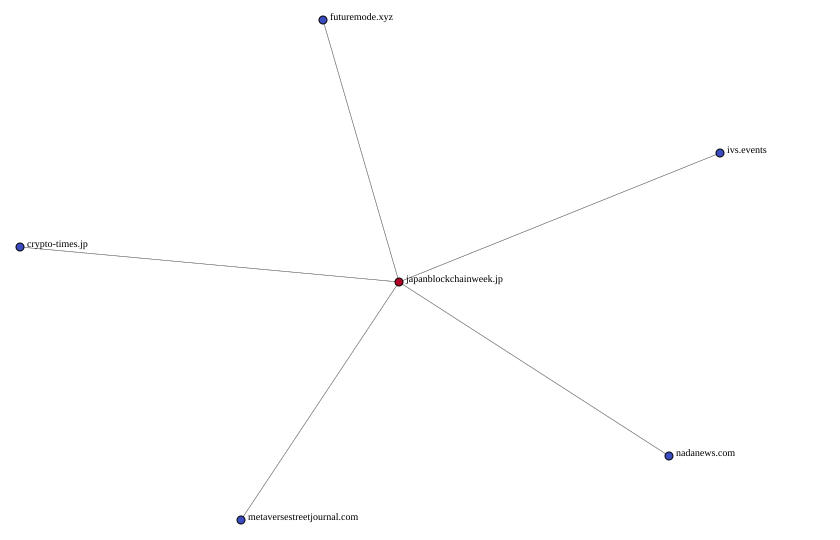

In [47]:
draw_ego(G, top_domains.index[33])


about.airporter.co.jp
busnavi-okinawa.com
chatan-gateway.com
nbus-nanjo.jp
okinawabus.com
okinawapass.com
secure.j-bus.co.jp


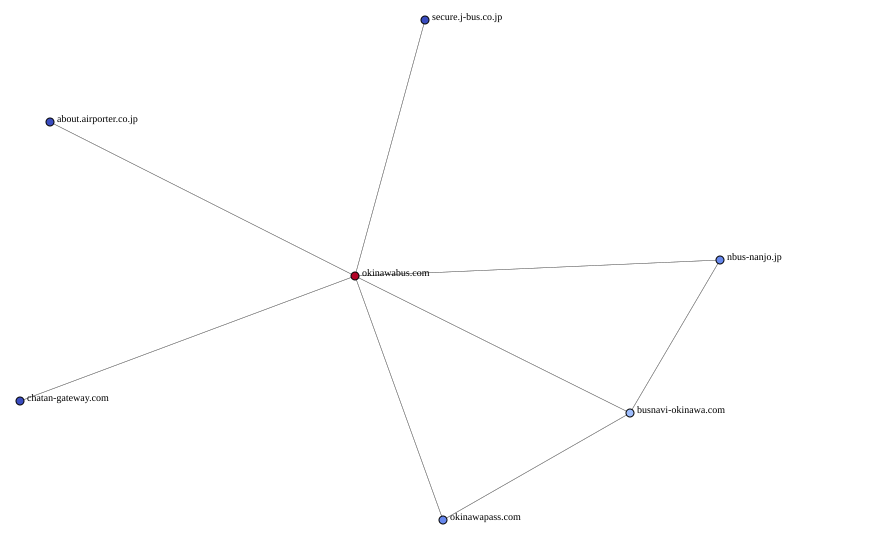

In [48]:
draw_ego(G, top_domains.index[34])


facebook.com
instagram.com
jrailpass.com
linkedin.com
pinterest.com
tiktok.com
trustpilot.com
twitter.com


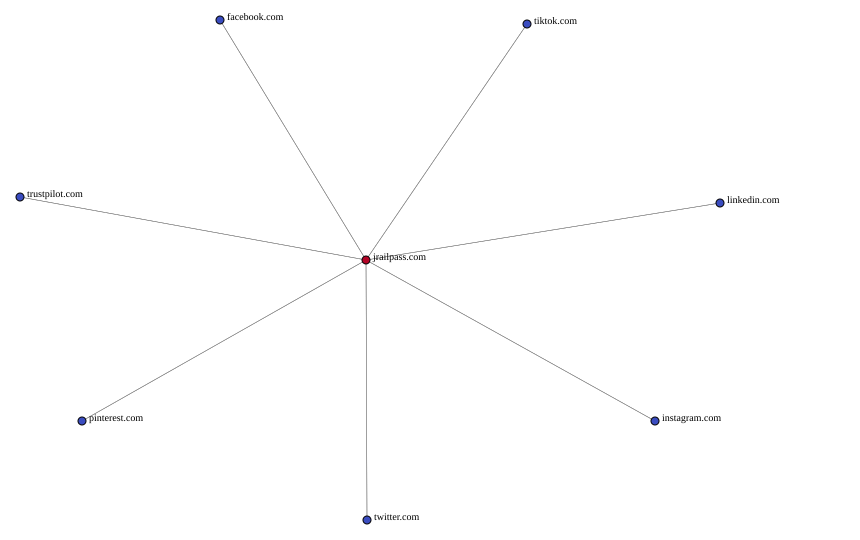

In [49]:
draw_ego(G, top_domains.index[35])


coindeskjapan.com
facebook.com
indices.nadanews.com
lin.ee
nadanews.com
navenue.jp
x.com


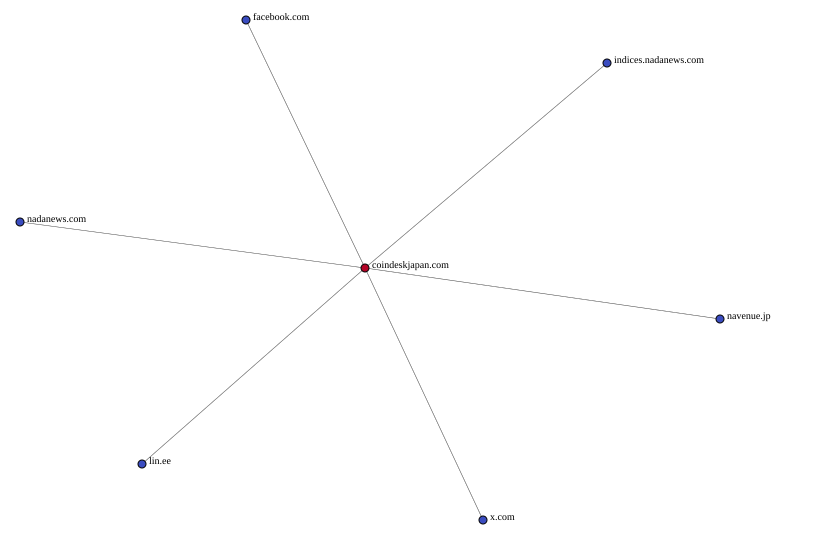

In [50]:
draw_ego(G, top_domains.index[36])


careers.tablecheck.com
facebook.com
instagram.com
itunes.apple.com
support-diners.tablecheck.com
tablecheck.com
x.com


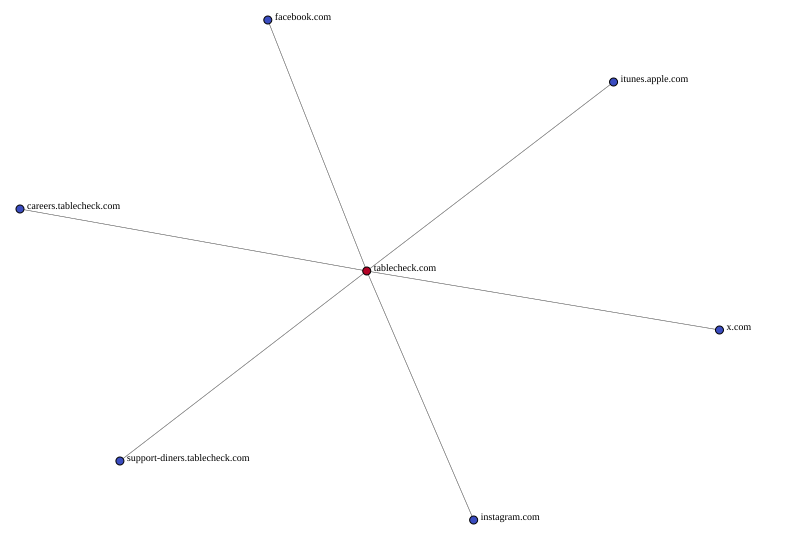

In [51]:
draw_ego(G, top_domains.index[37])


chiniquy.wordpress.com
okinawanews.org
subscribe.wordpress.com
wordpress.com


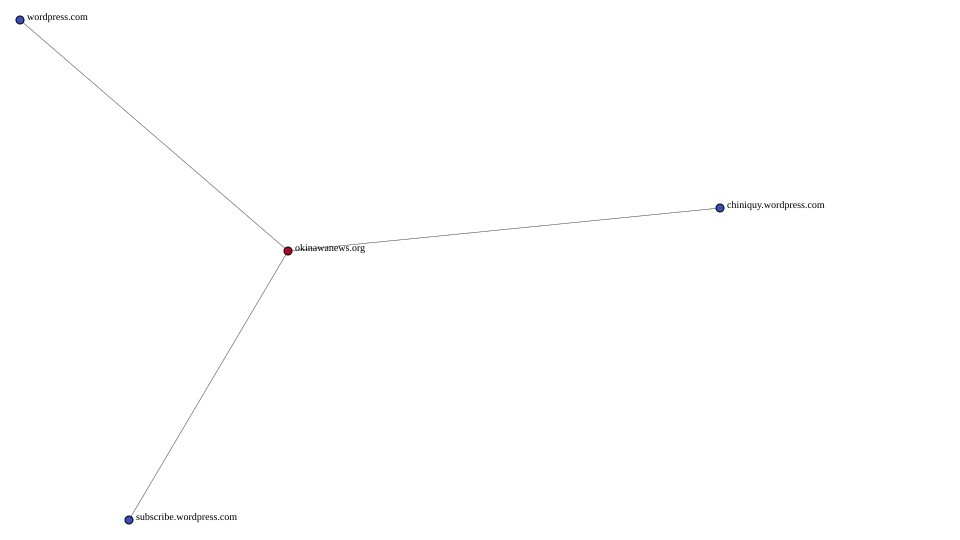

In [52]:
draw_ego(G, top_domains.index[38])


dmgevents.com
energyconnects.com
energydais.com
japanenergyevent.com


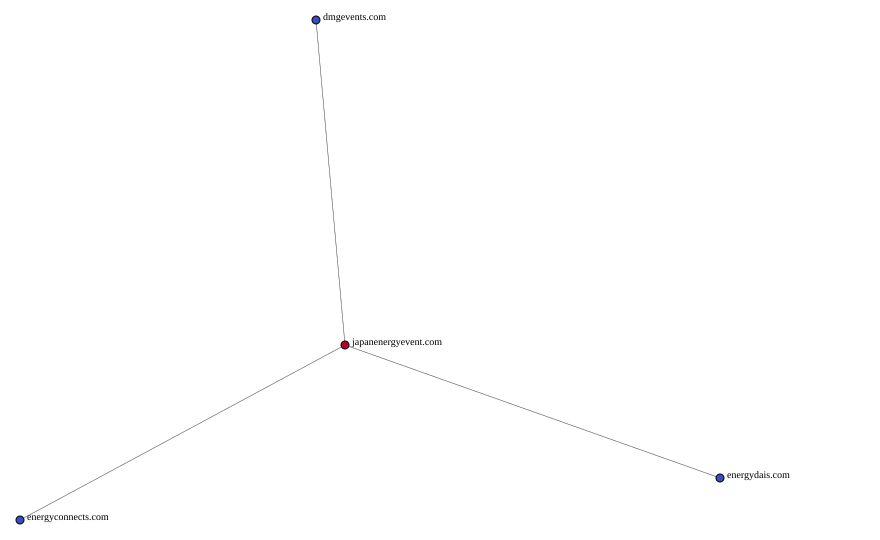

In [53]:
draw_ego(G, top_domains.index[39])


biz.jibtv.com
japanculturalexpo.bunka.go.jp
veltra.com
vividjapan.travel


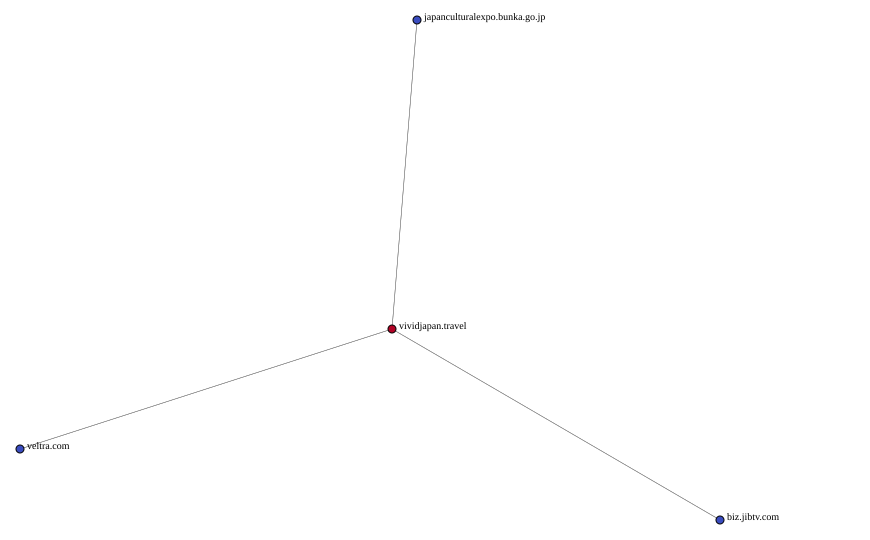

In [54]:
draw_ego(G, top_domains.index[40])